In [1]:
import torch, torch.nn as nn

class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64), nn.ReLU(),
            nn.Linear(64, 32),        nn.ReLU(),
            nn.Linear(32, 8),         nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(8, 32),         nn.ReLU(),
            nn.Linear(32, 64),        nn.ReLU(),
            nn.Linear(64, input_dim)
        )
    def forward(self, x):
        return self.decoder(self.encoder(x))

class LSTMAutoencoder(nn.Module):
    def __init__(self, step_dim, seq_len, hidden=64, latent=16):
        super().__init__()
        self.seq_len  = seq_len
        self.enc_lstm = nn.LSTM(step_dim, hidden, batch_first=True, num_layers=2, dropout=0.1)
        self.enc_fc   = nn.Linear(hidden, latent)
        self.dec_fc   = nn.Linear(latent, hidden)
        self.dec_lstm = nn.LSTM(hidden, hidden, batch_first=True, num_layers=2, dropout=0.1)
        self.out_fc   = nn.Linear(hidden, step_dim)
    def forward(self, x):
        _, (h, _) = self.enc_lstm(x)
        z         = self.enc_fc(h[-1])
        z_seq     = self.dec_fc(z).unsqueeze(1).repeat(1, self.seq_len, 1)
        dec, _    = self.dec_lstm(z_seq)
        return self.out_fc(dec)

import shap, pickle, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
import warnings; warnings.filterwarnings('ignore')

with open('../preprocessed_data.pkl', 'rb') as f:
    data = pickle.load(f)

FEATURES     = data['FEATURES']
X_test       = data['X_test']
y_test       = data['y_test']
lstm_preds   = data['lstm_ae_preds']
X_ctgan_test = pd.DataFrame(data['X_ctgan_test'], columns=FEATURES)
y_ctgan_test = data['y_ctgan_test']
lstm_p_ctgan = data['lstm_p_ctgan']
print('Data loaded.')

Data loaded.


In [2]:
print('Training surrogate RF to mimic LSTM-AE decisions...')
surrogate = RandomForestClassifier(
    n_estimators=300, max_depth=10,
    class_weight='balanced', random_state=42, n_jobs=-1)
surrogate.fit(X_test, lstm_preds)

surr_preds = surrogate.predict(X_test)
agreement  = (surr_preds == lstm_preds).mean()
print(f'Surrogate agreement with LSTM-AE: {agreement:.4f}')

Training surrogate RF to mimic LSTM-AE decisions...


Surrogate agreement with LSTM-AE: 0.9975


In [3]:
print('\nComputing SHAP values (may take ~1 min)...')
explainer   = shap.TreeExplainer(surrogate)
shap_values = explainer.shap_values(X_test)
sv = shap_values[1] if isinstance(shap_values, list) else shap_values
if sv.ndim == 3: sv = sv[:,:,1]

mean_shap = np.abs(sv).mean(axis=0)
shap_imp  = pd.Series(mean_shap, index=FEATURES).sort_values(ascending=False)

print('\nTop 12 features driving LSTM-AE anomaly detection:')
print(shap_imp.head(12).to_string())


Computing SHAP values (may take ~1 min)...



Top 12 features driving LSTM-AE anomaly detection:
network_in_kb             0.095458
traffic_density           0.075503
packet_rate               0.073926
network_asymmetry         0.046955
response_per_packet       0.043688
geo_location_variation    0.027944
service_access_count      0.025501
auth_rate                 0.024515
avg_response_time_ms      0.023469
network_out_kb            0.016080
failed_auth_attempts      0.015406
cpu_usage                 0.014720


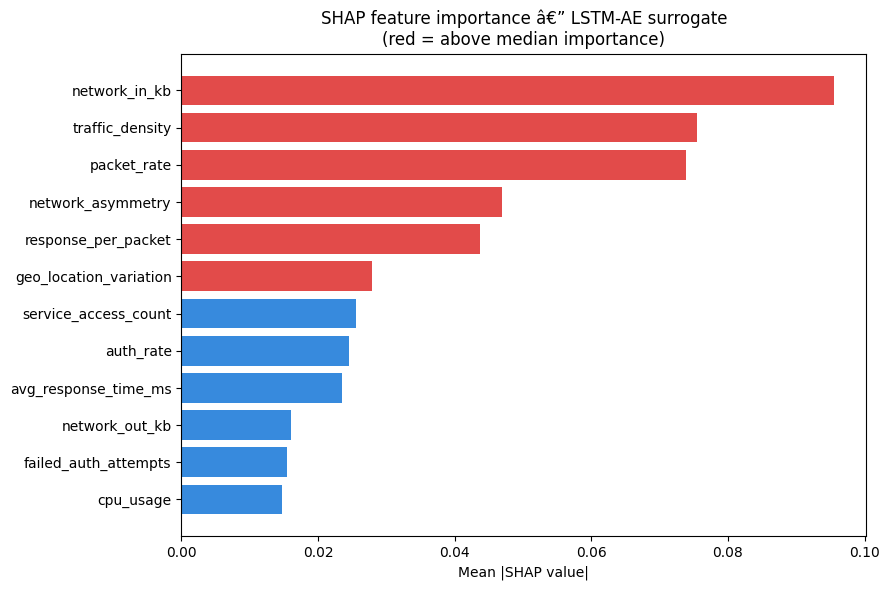

In [4]:
fig, ax = plt.subplots(figsize=(9, 6))
top12  = shap_imp.head(12)
colors = ['#E24B4A' if v > top12.median() else '#378ADD' for v in top12.values]
ax.barh(top12.index[::-1], top12.values[::-1], color=colors[::-1], edgecolor='none')
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('SHAP feature importance â€” LSTM-AE surrogate\n(red = above median importance)')
plt.tight_layout()
plt.savefig('../outputs/shap_importance.png', dpi=150)
plt.show()

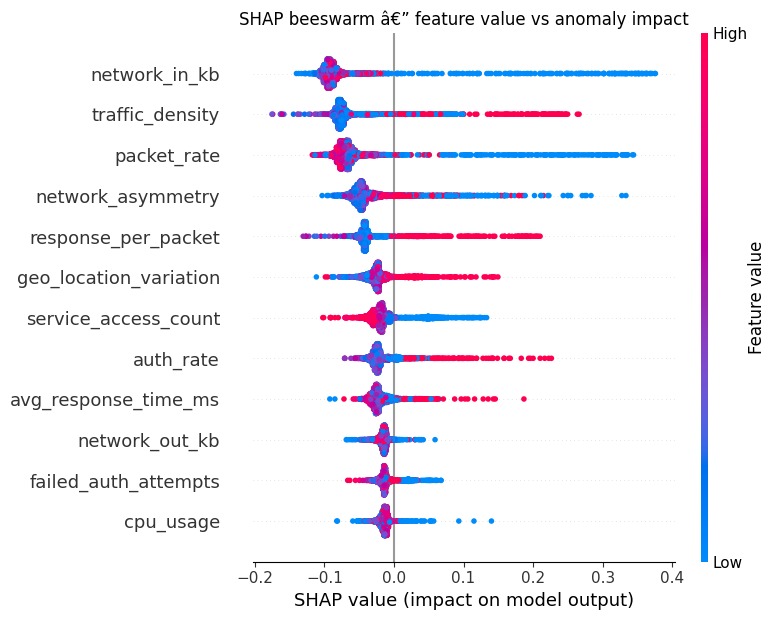

In [5]:
shap.summary_plot(sv, X_test, feature_names=FEATURES,
                  max_display=12, show=False)
plt.title('SHAP beeswarm â€” feature value vs anomaly impact')
plt.tight_layout()
plt.savefig('../outputs/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
shap_sum = sv.sum(axis=1)
prob     = surrogate.predict_proba(X_test)[:, 1]
log_odds = np.log(prob + 1e-8) - np.log(1 - prob + 1e-8)
fidelity = np.corrcoef(shap_sum, log_odds)[0, 1]
print(f'\nSHAP Fidelity (original test):  {fidelity:.4f}  (target > 0.80)')


SHAP Fidelity (original test):  0.9371  (target > 0.80)


In [7]:
np.random.seed(42)
noise     = np.random.normal(0, 0.02, X_test.shape)
X_noisy   = pd.DataFrame(X_test.values + noise, columns=FEATURES)
sv_noisy  = explainer.shap_values(X_noisy)
sv_noisy  = sv_noisy[1] if isinstance(sv_noisy, list) else sv_noisy
if sv_noisy.ndim == 3: sv_noisy = sv_noisy[:,:,1]

corrs = [np.corrcoef(sv[i], sv_noisy[i])[0,1]
         for i in range(len(sv))
         if np.std(sv[i]) > 1e-10 and np.std(sv_noisy[i]) > 1e-10]
stability = np.mean(corrs)
print(f'SHAP Stability (original test): {stability:.4f}  (target > 0.85)')

SHAP Stability (original test): 0.9816  (target > 0.85)


In [8]:
print('\n--- SHAP on CTGAN-augmented test set ---')
sv_c      = explainer.shap_values(X_ctgan_test)
sv_c      = sv_c[1] if isinstance(sv_c, list) else sv_c
if sv_c.ndim == 3: sv_c = sv_c[:,:,1]

prob_c    = surrogate.predict_proba(X_ctgan_test)[:,1]
log_c     = np.log(prob_c + 1e-8) - np.log(1 - prob_c + 1e-8)
fidelity_c= np.corrcoef(sv_c.sum(axis=1), log_c)[0,1]

noise_c   = np.random.normal(0, 0.02, X_ctgan_test.shape)
X_noisy_c = pd.DataFrame(X_ctgan_test.values + noise_c, columns=FEATURES)
sv_nc     = explainer.shap_values(X_noisy_c)
sv_nc     = sv_nc[1] if isinstance(sv_nc, list) else sv_nc
if sv_nc.ndim == 3: sv_nc = sv_nc[:,:,1]
corrs_c   = [np.corrcoef(sv_c[i], sv_nc[i])[0,1]
             for i in range(len(sv_c))
             if np.std(sv_c[i]) > 1e-10]
stability_c = np.mean(corrs_c)
print(f'SHAP Fidelity (CTGAN test):   {fidelity_c:.4f}')
print(f'SHAP Stability (CTGAN test):  {stability_c:.4f}')


--- SHAP on CTGAN-augmented test set ---


SHAP Fidelity (CTGAN test):   0.9025
SHAP Stability (CTGAN test):  0.9856


In [9]:
print('\n' + '='*55)
print('XAI QUALITY TABLE â€” copy into Chapter 4')
print('='*55)
print(f"\n{'Test set':<22} {'Fidelity':>10} {'Stability':>11}")
print('-'*45)
print(f"{'Original (weak sim)':<22} {fidelity:>10.4f} {stability:>11.4f}")
print(f"{'CTGAN (realistic)':<22} {fidelity_c:>10.4f} {stability_c:>11.4f}")
print('\n>>> Higher values = better explanation quality.')
print('>>> Difference between rows = your novel XAI finding.')


XAI QUALITY TABLE â€” copy into Chapter 4

Test set                 Fidelity   Stability
---------------------------------------------
Original (weak sim)        0.9371      0.9816
CTGAN (realistic)          0.9025      0.9856

>>> Higher values = better explanation quality.
>>> Difference between rows = your novel XAI finding.


In [10]:
data['shap_fidelity_orig']   = fidelity
data['shap_stability_orig']  = stability
data['shap_fidelity_ctgan']  = fidelity_c
data['shap_stability_ctgan'] = stability_c
data['shap_importance']      = shap_imp
with open('../preprocessed_data.pkl', 'wb') as f:
    pickle.dump(data, f)
print('\nAll experiments complete. Check ../outputs/ for all figures.')
print('You now have everything needed for your thesis Chapter 4.')


All experiments complete. Check ../outputs/ for all figures.
You now have everything needed for your thesis Chapter 4.
